**Inference of learned observer via SPINN**
    
1. **Niazi et al. (2025):** Sequential learning, PINN (SPINN)

**Benchmark System:**
1. Reverse Duffing Oscillator
2. Van der Pol Oscillator
3. Rossler attractor
4. Lorenz attractor

# Preamble

In [1]:
import torch
import torch.nn as nn
from torch import device
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

from tqdm.notebook import tqdm 
from IPython.display import display, clear_output

device = torch.device('cpu')

# System Definitions

First, we define the dynamics and output functions for our continuous-time benchmark systems. We also include an RK4 step function for the discrete-time methods.

In [2]:
class ReverseDuffing:
    def __init__(self):
        self.n_x = 2
        self.n_y = 1
        self.name = "ReverseDuffing"
        self.x_space_bounds = [(-1, 1), (-1, 1)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2**3
        dx2_dt = -x1
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1]  # y = x_1

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class VanDerPol:
    def __init__(self, mu=3.0):
        self.n_x = 2
        self.n_y = 1
        self.name = "VanDerPol"
        self.mu = mu
        self.x_space_bounds = [(-5, 5), (-5, 5)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2
        dx2_dt = self.mu * (1 - x1**2) * x2 - x1
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1] # y = x_1

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

class Rossler:
    def __init__(self, a=0.2, b=0.2, c=5.7):
        self.n_x = 3
        self.n_y = 1
        self.name = "Rossler"
        self.a, self.b, self.c = a, b, c
        self.x_space_bounds = [(-10, 10), (-10, 10), (0, 20)]

    def f(self, t, x):
        x1, x2, x3 = x
        dx1_dt = -x2 - x3
        dx2_dt = x1 + self.a * x2
        dx3_dt = self.b + x3 * (x1 - self.c)
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 1:2] # y = x_2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

class Lorenz:
    def __init__(self, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
        self.n_x = 3
        self.n_y = 1
        self.name = "Lorenz"
        self.sigma, self.rho, self.beta = sigma, rho, beta
        self.x_space_bounds = [(-20, 20), (-30, 30), (0, 50)]

    def f(self, t, x):
        x1, x2, x3 = x
        dx1_dt = self.sigma * (x2 - x1)
        dx2_dt = x1 * (self.rho - x3) - x2
        dx3_dt = x1 * x2 - self.beta * x3
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 1:2] # y = x_2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

# Helper Functions & Common Components

Generic MLP class and other functions to create observer matrices.

## MLP modules

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims, activation=nn.ReLU):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            # Check if activation is a class or an instance
            if isinstance(activation, nn.Module): # If it's already an instance
                 layers.append(activation)
            else: # Assume it's a class and instantiate it
                 layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Sample x space

In [4]:
# sample_x0 accepts state space bounds directly
def sample_x0(bounds, n_samples):
    samples = []
    # Ensure bounds are in (min, max) format
    if isinstance(bounds, list) and isinstance(bounds[0], tuple):
        for (low, high) in bounds:
            samples.append(np.random.uniform(low, high, n_samples))
    else: # Fallback for simple (min, max) array
        low, high = bounds
        samples.append(np.random.uniform(low, high, (n_samples, len(low))))
        return samples[0]

    return np.stack(samples, axis=-1).squeeze()

# sample_x_points samples uniformly from a hyperrectangle defined by min_vals and max_vals
def sample_x_points(min_vals: torch.Tensor, max_vals: torch.Tensor, n_samples: int) -> torch.Tensor:
    n_dim = min_vals.shape[0]
    # Generate random numbers between 0 and 1
    rand_samples = torch.rand(n_samples, n_dim, device=min_vals.device)
    # Scale to desired range
    return min_vals + rand_samples * (max_vals - min_vals)

## Create observer matrices

In [5]:
def create_observer_matrices(n_z, n_y, system_name, strategy='diagonal', base_eig=-1.5, device='cpu'):
    """
    Creates a stable A matrix and a B matrix such that (A,B) is controllable.
    For chaotic systems like Lorenz, 'random_stable' enforces a strict eigenvalue 
    spectrum [-3.0, -1.5] to balance injectivity and floating-point precision.
    """
    if strategy == 'random_stable':
        print(f"Using densely coupled A (strict eigenvalues) and random B for {system_name}.")
        
        # 1. Sample eigenvalues strictly in the Goldilocks Zone (-3.0 to -1.5)
        # We use numpy for the QR decomposition as it is mathematically robust
        min_eig = -3.0
        max_eig = -1.5
        eigenvalues = np.random.uniform(min_eig, max_eig, size=n_z)
        D = np.diag(eigenvalues)
        
        # 2. Create a random orthogonal transformation matrix (Q)
        # This creates a dense, highly coupled A matrix without altering the eigenvalues
        H = np.random.randn(n_z, n_z)
        Q, R = np.linalg.qr(H)
        
        # 3. Calculate A = Q * D * Q^T
        A_np = Q @ D @ Q.T
        
        # 4. Generate a random dense B matrix (better for multi-dimensional outputs than ones)
        B_np = np.random.randn(n_z, n_y)
        
        # Cast to PyTorch tensors and push to the correct device
        A = torch.tensor(A_np, dtype=torch.float32, device=device)
        B = torch.tensor(B_np, dtype=torch.float32, device=device)

    elif strategy == 'diagonal':
         print(f"Using diagonal A and ones B for system {system_name}.")
         # Maintain legacy diagonal support if needed
         eigs = torch.linspace(base_eig, base_eig * 3, n_z)
         A = torch.diag(eigs).to(device)
         B = torch.ones((n_z, n_y)).to(device)

    else:
        print(f"Unknown matrix strategy '{strategy}'. Defaulting to diagonal A.")
        eigs = torch.linspace(base_eig, base_eig * 4, n_z)
        A = torch.diag(eigs).to(device)
        B = torch.ones((n_z, n_y)).to(device)

    return A, B

## Data normalization

In [6]:
# Data standardization / normalization

def scale_minmax(data, data_min, data_max):
    """Applies Min-Max scaling to [-1, 1]."""
    data_range = data_max - data_min
    data_range[data_range == 0] = 1e-8 # Avoid division by zero
    return 2.0 * (data - data_min) / data_range - 1.0

def unscale_minmax(scaled_data, data_min, data_max):
    """Applies inverse Min-Max scaling from [-1, 1]."""
    data_range = data_max - data_min
    data_range[data_range == 0] = 1e-8
    return (scaled_data + 1.0) / 2.0 * data_range + data_min

## Observer class

In [47]:
import torch
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

class Observer:
    def __init__(self, system, A_obs, B_obs, net, t0, tf, N, init_z_zero, scaling_params):
        """
        KKL Observer class

        Args:
            system: The system object (must have f, h, n_x, n_y).
            A_obs: The observer matrix A (torch tensor or numpy array) for system dynamics.
            B_obs: The observer matrix B (torch tensor or numpy array) for system dynamics.
            net: The neural network for the inverse transformation (T_inv_net).
                 (Assumes t_inv_net maps z_scaled -> x_scaled)
            t0: Start time of simulation.
            tf: End time of simulation.
            N: Number of time steps.
            init_z_zero: If True, initialize observer state z(0) to zero (unscaled).
            scaling_params: A dictionary containing min/max tensors for x, y, and z.
        """
        self.system = system

        # Hardware-agnostic initialization
        device = next(net.parameters()).device

        self.A_obs = A_obs.clone().detach().to(device) if isinstance(A_obs, torch.Tensor) else torch.tensor(A_obs, dtype=torch.float32).to(device)
        self.B_obs = B_obs.clone().detach().to(device) if isinstance(B_obs, torch.Tensor) else torch.tensor(B_obs, dtype=torch.float32).to(device)
        self.net = net.to(device) # The inverse map (T_inv_net)

        self.t0 = t0
        self.tf = tf
        self.N = N
        self.dt = (tf - t0) / N
        self.t_eval_torch = torch.tensor(np.linspace(t0, tf, N + 1), dtype=torch.float32).to(device)

        self.init_z_zero = init_z_zero
        self._initial_z_unscaled = torch.zeros(self.A_obs.shape[0], dtype=torch.float32).to(device) if init_z_zero else None

        # Store scaling parameters
        self.x_min = scaling_params['x_min'].to(device)
        self.x_max = scaling_params['x_max'].to(device)
        self.z_min = scaling_params['z_min'].to(device)
        self.z_max = scaling_params['z_max'].to(device)
        self.y_min = scaling_params['y_min'].to(device)
        self.y_max = scaling_params['y_max'].to(device)

    def simulate(self, t_eval_torch, y_data_torch):
        """
        Simulates the KKL observer (z dynamics in UNSCALED space) and estimates x (unscaled).
        """
        n_z = self.A_obs.shape[0]
        n_y = self.system.n_y
        # n_x = self.system.n_x
        
        device = y_data_torch.device

        # Initial condition for z observer
        z0_observer_unscaled = torch.zeros(n_z, dtype=torch.float32).to(device) if self.init_z_zero else self._initial_z_unscaled
        if z0_observer_unscaled is None:
            raise ValueError("Observer must be initialized with z(0) or init_z_zero=True")


        # --- NOISE INJECTION ---
        # Mathematically explicit measurement corruption: y_noisy = y_true + v(t), v(t) ~ N(0, 0.5^2)
        noise_std = 0.5
        y_noisy_torch = y_data_torch + torch.randn_like(y_data_torch) * noise_std

        # Create an interpolator for the y_data
        # y_data_np = y_data_torch.cpu().numpy()
        y_data_np = y_noisy_torch.cpu().numpy()
        t_eval_np = t_eval_torch.cpu().numpy()

        # Use scipy.interpolate.interp1d for robust interpolation
        if n_y == 1:
            y_data_np_interp = y_data_np.squeeze(-1)
        else:
            y_data_np_interp = y_data_np

        y_interp_func_unscaled = interp1d(
            t_eval_np,
            y_data_np_interp,
            axis=0,
            kind='cubic', # linear/cubic
            bounds_error=False,
            fill_value="extrapolate"
        )

        # --- OPTIMIZATION: Pure NumPy Z-Dynamics ---
        A_np = self.A_obs.cpu().numpy()
        B_np = self.B_obs.cpu().numpy()
        z0_np = z0_observer_unscaled.cpu().numpy()

        def observer_z_dynamics_np(t, z):
            y_t = y_interp_func_unscaled(t)
            return A_np @ z + B_np @ np.atleast_1d(y_t)

        # Solve using the stiff-aware LSODA algorithm
        sol_z = solve_ivp(
            observer_z_dynamics_np,
            [t_eval_np[0], t_eval_np[-1]],
            z0_np,
            t_eval=t_eval_np,
            method='LSODA'
        )

        # Move the ENTIRE finished trajectory back to the device in one shot
        # z_traj_torch_unscaled = torch.tensor(sol_z.y.T, dtype=torch.float32).to(device)
        z_traj_torch_unscaled = torch.from_numpy(sol_z.y.T).float().to(device)


        # # --- Network Gating (Batched Evaluation) ---
        # # 1. Scale the entire Z trajectory
        # z_traj_torch_scaled = scale_minmax(z_traj_torch_unscaled, self.z_min, self.z_max)

        # # 2. Estimate scaled X in one massive parallel shot
        # with torch.no_grad():
        #     x_hat_traj_torch_scaled = self.net(z_traj_torch_scaled)

        # # 3. Unscale the estimated x trajectory
        # x_hat_traj_torch_unscaled = unscale_minmax(x_hat_traj_torch_scaled, self.x_min, self.x_max)
        # --- Network Gating (Batched Evaluation) ---
        # Context manager for maximum inference speed (disables autograd and version tracking)
        with torch.inference_mode():
            # 1. Scale the entire Z trajectory
            z_traj_torch_scaled = scale_minmax(z_traj_torch_unscaled, self.z_min, self.z_max)

            # 2. Estimate scaled X in one massive parallel shot
            x_hat_traj_torch_scaled = self.net(z_traj_torch_scaled)

        # 3. Unscale the estimated x trajectory
        x_hat_traj_torch_unscaled = unscale_minmax(x_hat_traj_torch_scaled, self.x_min, self.x_max)

        return z_traj_torch_unscaled, x_hat_traj_torch_unscaled
    


## Simulate and plot function

In [88]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==============================================================================
# 1. Global Plotting Configuration (Publication-Ready)
# ==============================================================================
def set_global_plot_style():
    """Sets global matplotlib parameters for consistent, publication-ready figures."""
    plt.rcParams.update({
        'font.family': 'serif',
        'figure.titlesize': 18,        # Suptitle font size
        'figure.titleweight': 'bold',  # Suptitle font weight
        'axes.titlesize': 16,          # Individual subplot title size
        'axes.titleweight': 'bold',    # Individual subplot title weight
        'axes.labelsize': 16,          # X and Y label font size
        'xtick.labelsize': 14,         # X tick numbers
        'ytick.labelsize': 14,         # Y tick numbers
        'legend.fontsize': 16,         # Legend text
        'legend.title_fontsize': 16,   # Legend title
        'lines.linewidth': 1.5,        # Default line width
        'axes.grid': True,             # Turn on grid by default
        'grid.linestyle': '--',        # Grid line style
        'grid.alpha': 0.6              # Grid transparency
    })

# Apply the global style immediately
set_global_plot_style()


# ==============================================================================
# 2. Optimized Inference & Plotting Router
# ==============================================================================
def simulate_and_plot(kkl_observer, x0_test_torch, title="KKL Observer Estimation", plot_mode="time_series", filename=None, figsize=(10, 6)):
    """
    Simulates the true system and the KKL observer, applying optimal inference modes,
    and supports multiple visualization paradigms including time-evolution SMAPE.

    Args:
        kkl_observer: An instance of the Observer class
        x0_test_torch: Initial condition for true system (torch tensor, shape (n_x,)).
        title: Title for the plot.
        plot_mode: 'time_series', 'phase_space', 'log_error', 'scatter', or 'smape_time'.
    """
    system = kkl_observer.system
    t_eval_torch = kkl_observer.t_eval_torch
    t_eval_np = t_eval_torch.cpu().numpy()

    # 1. Simulate the true system (LSODA for stiff continuous dynamics)
    t_span = [kkl_observer.t0, kkl_observer.tf]
    x0_test_np = x0_test_torch.cpu().numpy().flatten()

    sol = solve_ivp(system.f, t_span, x0_test_np, t_eval=t_eval_np, method='LSODA')
    x_true_np = sol.y.T 
    y_true_np = system.h(x_true_np)

    # 2. Simulate the KKL observer with extreme inference optimization
    # Zero-copy memory mapping from numpy array to avoid allocation overhead
    y_true_torch = torch.from_numpy(y_true_np).float().to(x0_test_torch.device)

    # Maximum inference speed: Disables autograd tracking and version counter bumps
    with torch.inference_mode():
        _, x_hat_traj_unscaled = kkl_observer.simulate(t_eval_torch, y_true_torch)
        x_hat_np = x_hat_traj_unscaled.cpu().numpy()

    # =========================================================
    # 3. Dynamic Plotting Router (Font sizes governed by rcParams)
    # =========================================================
    
    if plot_mode == "time_series":
        fig, axes = plt.subplots(system.n_x, 1, figsize=(12, 2 * system.n_x))
        if system.n_x == 1: axes = [axes]
            
        for i, ax in enumerate(axes):
            ax.plot(t_eval_np, x_true_np[:, i], 'k-', label=f'True $x_{i+1}$')
            ax.plot(t_eval_np, x_hat_np[:, i], 'm--', label=f'Estimated $\hat{{x}}_{i+1}$')
            ax.set_ylabel(f'$x_{i+1}$')
            ax.legend(loc='upper right')
            
        axes[-1].set_xlabel('Time ($t$)')
        fig.suptitle(title)
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])

        # Save the figure if a filename is provided
        if filename:
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Figure saved successfully to: {filename}")
            
        plt.show()
        
    elif plot_mode == "phase_space":
        fig = plt.figure(figsize=(10, 8))
        
        if system.n_x == 2:
            ax = fig.add_subplot(111)
            ax.plot(x_true_np[:, 0], x_true_np[:, 1], 'k-', alpha=0.7, label='True Attractor Manifold')
            ax.plot(x_hat_np[:, 0], x_hat_np[:, 1], 'm--', alpha=0.9, label='Learned Observer $\hat{\mathcal{T}}_\eta^*$')
            ax.set_xlabel('$x_1$')
            ax.set_ylabel('$x_2$')
        
        elif system.n_x >= 3:
            ax = fig.add_subplot(111, projection='3d')
            ax.plot(x_true_np[:, 0], x_true_np[:, 1], x_true_np[:, 2], 'k-', alpha=0.5, label='True Attractor')
            ax.plot(x_hat_np[:, 0], x_hat_np[:, 1], x_hat_np[:, 2], 'm--', alpha=0.9, label='Learned Observer')
            ax.set_xlabel('$x_1$')
            ax.set_ylabel('$x_2$')
            ax.set_zlabel('$x_3$')
            
        ax.set_title(f"{title} (Phase Space)")
        ax.legend()
        
    elif plot_mode == "log_error":
        fig, ax = plt.subplots(figsize=(10, 5))
        # Compute L2 norm of the estimation error vector xi(t) = x(t) - x_hat(t)
        error_norm = np.linalg.norm(x_true_np - x_hat_np, axis=1)
        log_error = np.log10(error_norm + 1e-12) # Epsilon prevents log10(0)
        
        ax.plot(t_eval_np, log_error, 'r-')
        ax.set_xlabel('Time ($t$)')
        ax.set_ylabel('$\log_{10}(||\epsilon(t)||_2)$')
        ax.set_title(f"{title} ($L_2$ Error Evolution)")
        
    elif plot_mode == "smape_time":
        fig, ax = plt.subplots(figsize=(10, 5))
        
        # Calculate SMAPE per time step (highly optimized vectorization)
        numerator = 2.0 * np.abs(x_true_np - x_hat_np)
        denominator = np.abs(x_true_np) + np.abs(x_hat_np) + 1e-8 
        
        smape_time = np.mean((numerator / denominator) * 100.0, axis=1)
        
        ax.plot(t_eval_np, smape_time, 'r-')
        ax.set_xlabel('Time ($t$)')
        ax.set_ylabel('SMAPE (%)')
        ax.set_title(f"{title} (SMAPE Evolution)")

    elif plot_mode == "scatter":
        fig, axes = plt.subplots(1, system.n_x, figsize=(4 * system.n_x, 4))
        if system.n_x == 1: axes = [axes]
            
        for i, ax in enumerate(axes):
            ax.scatter(x_true_np[:, i], x_hat_np[:, i], s=2, c='blue', alpha=0.3)
            # Plot y=x reference boundary
            limits = [np.min(x_true_np[:, i]), np.max(x_true_np[:, i])]
            ax.plot(limits, limits, 'k--', alpha=0.8, label='$y=x$')
            
            ax.set_xlabel(f'True $x_{i+1}$')
            ax.set_ylabel(f'Predicted $\hat{{x}}_{i+1}$')
            ax.set_title(f'State $x_{i+1}$ Identity Mapping')
            ax.legend()
            
        fig.suptitle(f"{title} (Identity Scatter)")
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
        
    else:
        print(f"Unknown plot_mode: {plot_mode}")
        return

    plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\h'
<>:98: SyntaxWarning: invalid escape sequence '\h'
<>:121: SyntaxWarning: invalid escape sequence '\l'
<>:149: SyntaxWarning: invalid escape sequence '\h'
<>:77: SyntaxWarning: invalid escape sequence '\h'
<>:98: SyntaxWarning: invalid escape sequence '\h'
<>:121: SyntaxWarning: invalid escape sequence '\l'
<>:149: SyntaxWarning: invalid escape sequence '\h'
/var/folders/x0/491fxsj52ms_1ssdtl5sm1lc0000gn/T/ipykernel_93877/384801995.py:77: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(t_eval_np, x_hat_np[:, i], 'm--', label=f'Estimated $\hat{{x}}_{i+1}$')
/var/folders/x0/491fxsj52ms_1ssdtl5sm1lc0000gn/T/ipykernel_93877/384801995.py:98: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(x_hat_np[:, 0], x_hat_np[:, 1], 'm--', alpha=0.9, label='Learned Observer $\hat{\mathcal{T}}_\eta^*$')
/var/folders/x0/491fxsj52ms_1ssdtl5sm1lc0000gn/T/ipykernel_93877/384801995.py:121: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabe

# Inference: SPINN (Our method)

## Reverse Duffing

--- Loading SPINN Model for Inference ---
Using diagonal A and ones B for system ReverseDuffing.
Successfully loaded checkpoint from kkl_models_reverseduffing.pth

--- Simulating Observer Estimation for ReverseDuffing ---
Figure saved successfully to: Estimation_ReverseDuffing.png


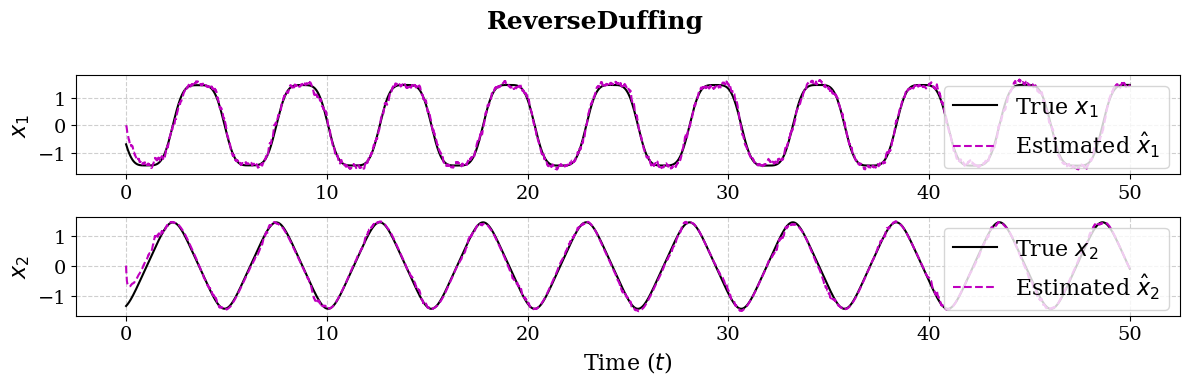

In [93]:
print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = ReverseDuffing()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1.5
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print(f"\n--- Simulating Observer Estimation for {system.name} ---")
# simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")
# 1. Standard Time Series Unrolling
simulate_and_plot(
    kkl_observer, 
    ic_test_torch, 
    title=f"{system.name}", 
    plot_mode="time_series",
    filename=f"Estimation_{system.name}.png",  # <--- Saves the figure here
    figsize=(10, 6)                            # <--- Enforces uniform sizing
)

# 2. 3D Phase Space Attractor Topology
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="phase_space")

# 3. Asymptotic Contraction and Noise Floor Limit
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="log_error")

# 4. Out-of-Domain Amplification Check
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="scatter")

## VdP

--- Loading SPINN Model for Inference ---
Using diagonal A and ones B for system VanDerPol.
Successfully loaded checkpoint from kkl_models_vanderpol.pth

--- Simulating Observer Estimation for VanDerPol ---
Figure saved successfully to: Estimation_VanDerPol.png


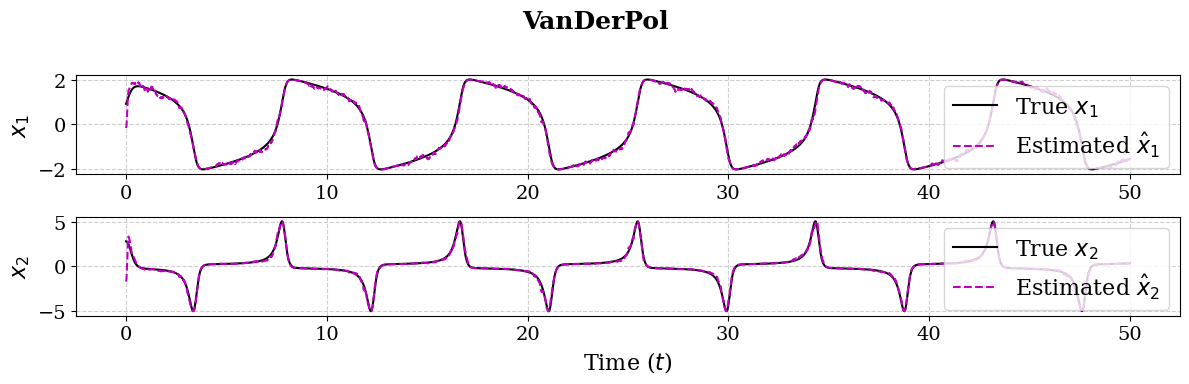

In [94]:
print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = VanDerPol()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print(f"\n--- Simulating Observer Estimation for {system.name} ---")
# simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")
# 1. Standard Time Series Unrolling
simulate_and_plot(
    kkl_observer, 
    ic_test_torch, 
    title=f"{system.name}", 
    plot_mode="time_series",
    filename=f"Estimation_{system.name}.png",  # <--- Saves the figure here
    figsize=(10, 6)                            # <--- Enforces uniform sizing
)

# 2. 3D Phase Space Attractor Topology
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="phase_space")

# 3. Asymptotic Contraction and Noise Floor Limit
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="log_error")

# 4. Out-of-Domain Amplification Check
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="scatter")

## Rossler

--- Loading SPINN Model for Inference ---
Using diagonal A and ones B for system Rossler.
Successfully loaded checkpoint from kkl_models_rossler.pth

--- Simulating Observer Estimation for Rossler ---
Figure saved successfully to: Estimation_Rossler.png


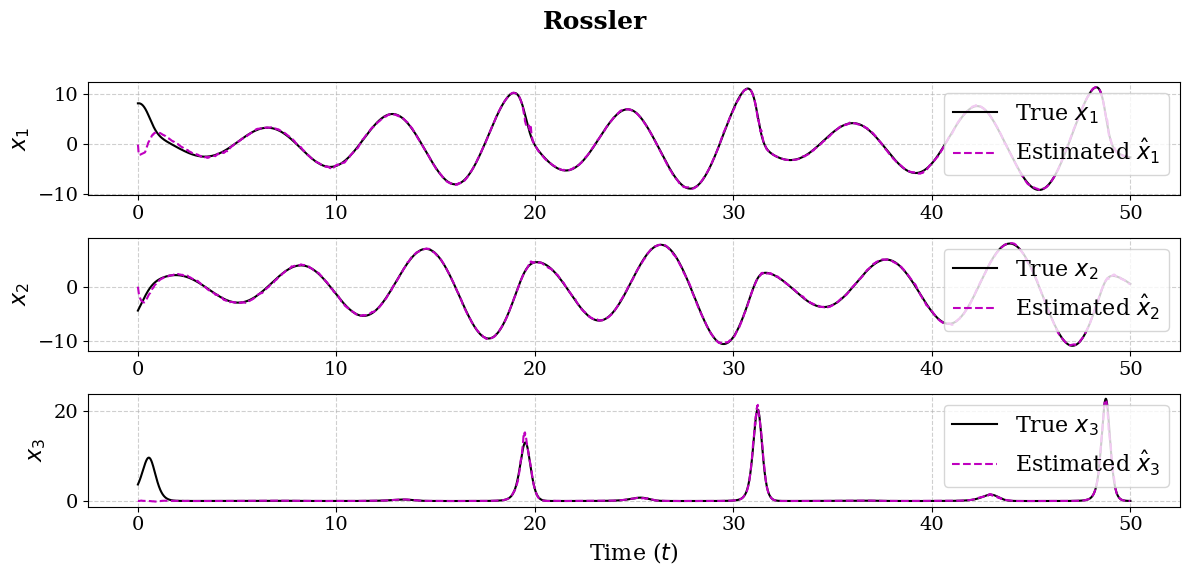

In [97]:
print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = Rossler()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print(f"\n--- Simulating Observer Estimation for {system.name} ---")
# simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")
# 1. Standard Time Series Unrolling
simulate_and_plot(
    kkl_observer, 
    ic_test_torch, 
    title=f"{system.name}", 
    plot_mode="time_series",
    filename=f"Estimation_{system.name}.png",  # <--- Saves the figure here
    figsize=(10, 6)                            # <--- Enforces uniform sizing
)

# 2. 3D Phase Space Attractor Topology
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="phase_space")

# 3. Asymptotic Contraction and Noise Floor Limit
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="log_error")

# 4. Out-of-Domain Amplification Check
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="scatter")

## Lorenz

--- Loading SPINN Model for Inference ---
Using diagonal A and ones B for system Lorenz.
Successfully loaded checkpoint from kkl_models_lorenz.pth

--- Simulating Observer Estimation for Lorenz ---
Figure saved successfully to: Estimation_Lorenz.png


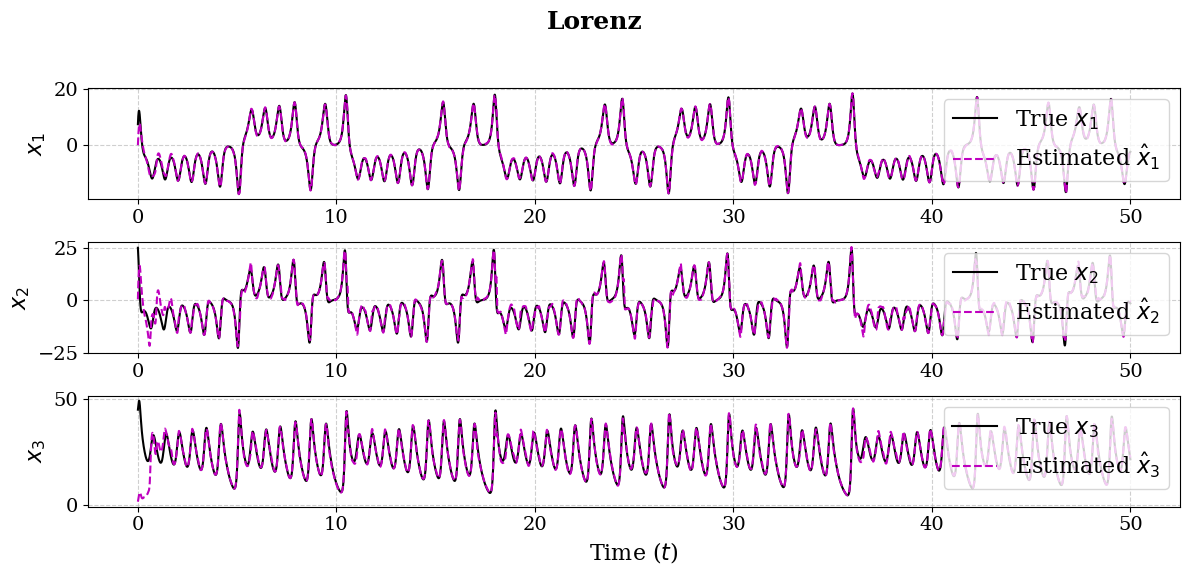

In [92]:
print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = Lorenz()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print(f"\n--- Simulating Observer Estimation for {system.name} ---")
# simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")
# 1. Standard Time Series Unrolling
simulate_and_plot(
    kkl_observer, 
    ic_test_torch, 
    title=f"{system.name}", 
    plot_mode="time_series",
    filename=f"Estimation_{system.name}.png",  # <--- Saves the figure here
    figsize=(10, 6)                            # <--- Enforces uniform sizing
)

# 2. 3D Phase Space Attractor Topology
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="phase_space")

# 3. Asymptotic Contraction and Noise Floor Limit
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="log_error")

# 4. SMAPE in time
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="smape_time")

# 4. Out-of-Domain Amplification Check
# simulate_and_plot(kkl_observer, ic_test_torch, f"{system.name}", plot_mode="scatter")